In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

taxlevels = ['domain','phylum','class','order','family','genus','species']
taxlevels_rev = list(reversed(taxlevels))
dict_tax = {taxlevels_rev[i]: i for i in range(len(taxlevels_rev))} # taxonomic level to number (species=0, ..., domain=6)

def get_unique_level(x, level='votu_id'):
    for t in taxlevels_rev:
        if x[t].nunique() == 1:
            return pd.DataFrame({level: x[level].unique(), 'unique_level': t, 'unique_taxon': x[t].unique()})
    return pd.DataFrame({level: x[level].unique(), 'unique_level': 'NA', 'unique_taxon': 'NA'}) # 'NA' = infects >1 domain

phyla2plot = ['Firmicutes','Bacteroidota','Actinobacteriota','Proteobacteria','Desulfobacterota']

Host associations by linkage method

In [2]:
df_pr = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='prophage', usecols=['votu_id','sample_id'] + taxlevels).drop_duplicates()
df_pr['linkage_method'] = 'pr'
df_sp = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='spacer matching', usecols=['votu_id','sample_id'] + taxlevels).drop_duplicates()
df_sp['linkage_method'] = 'sp'
df_hc = pd.read_excel('../data/Supplementary_Data_6_virus-host_associations.xlsx', sheet_name='Hi-C', usecols=['votu_id','sample_id'] + taxlevels).drop_duplicates()
df_hc['linkage_method'] = 'hc'

df = pd.concat([df_pr, df_sp, df_hc], ignore_index=True)

Group Firmicutes, Firmicutes_A, Firmicutes_B, and Firmicutes_C as "Firmicutes" for host range specificity analysis, since they are closely related and often have similar phages infecting them.

In [3]:
df = df.rename(columns={'phylum': 'phylum0'})
df['phylum'] = np.where(df.phylum0.str.startswith('Firmicutes'), 'Firmicutes', df.phylum0)

In [4]:
sns.set_style('whitegrid')
sns.color_palette('deep')
colors = ['C3','C2','C0','C1','purple']

### Fig. 2E: host range of vOTUs by phylum

In [5]:
df_bhr_votu_p = pd.DataFrame()

for p in phyla2plot:
    df_phylum = df.loc[df.phylum == p]
    df1 = df_phylum.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
    df1['phylum'] = p
    df_bhr_votu_p = pd.concat([df_bhr_votu_p, df1])

df_bhr_votu_p['unique_level1'] = df_bhr_votu_p.unique_level.map(dict_tax)

C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\548149404.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df_phylum.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\548149404.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df_phylum.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=

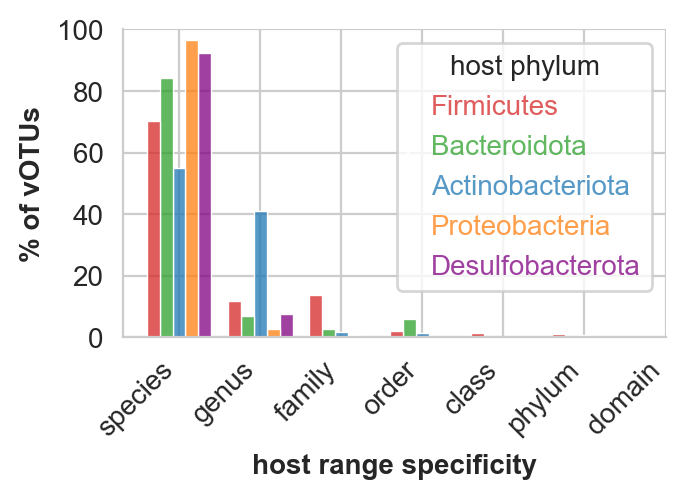

In [6]:
fig, ax = plt.subplots(figsize=(3.5,2), dpi=200)

sns.histplot(data=df_bhr_votu_p, x='unique_level1', stat='percent', discrete=True, hue='phylum', multiple='dodge', shrink=.8, common_norm=False, ax=ax, palette = colors)

plt.xticks(range(7), taxlevels_rev, rotation=45, ha='right')
plt.xlabel('host range specificity', fontweight='bold')
plt.ylim(0,100)
plt.ylabel('% of vOTUs', fontweight='bold')

legend = ax.get_legend()
legend_handles = legend.legend_handles
ax.legend(legend_handles, phyla2plot, title='host phylum', loc='upper right', labelcolor='linecolor', handlelength=0)

sns.despine()

In [7]:
from scipy.stats import mannwhitneyu

target = "Firmicutes"

firm = df_bhr_votu_p.loc[df_bhr_votu_p["phylum"] == target, "unique_level1"]
others = df_bhr_votu_p.loc[df_bhr_votu_p["phylum"] != target, "unique_level1"]

stat, p = mannwhitneyu(firm, others, alternative="greater")
print(f"Firmicutes > Others: U={stat:.0f}, p={p:.1g}")

mean_firm = firm.mean()
mean_others = others.mean()
print(f"Firmicutes mean = {mean_firm:.2f}, Others mean = {mean_others:.2f}")

Firmicutes > Others: U=28832336, p=3e-37
Firmicutes mean = 0.56, Others mean = 0.31


### Fig. 2F: host range of VFCs by phylum

In [8]:
df_v = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id','VFC'])

df = df.merge(df_v, on='votu_id', how='left')

In [9]:
df_bhr_vfc_p = pd.DataFrame()

for p in phyla2plot:
    df_phylum = df.loc[df.phylum == p]
    df1 = df_phylum.groupby('VFC', group_keys=False).apply(get_unique_level, level='VFC').reset_index(drop=True)
    df1['phylum'] = p
    df_bhr_vfc_p = pd.concat([df_bhr_vfc_p, df1])

df_bhr_vfc_p['unique_level1'] = df_bhr_vfc_p.unique_level.map(dict_tax)

C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\3570340876.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df_phylum.groupby('VFC', group_keys=False).apply(get_unique_level, level='VFC').reset_index(drop=True)
C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\3570340876.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df_phylum.groupby('VFC', group_keys=False).apply(get_unique_level, level='VFC

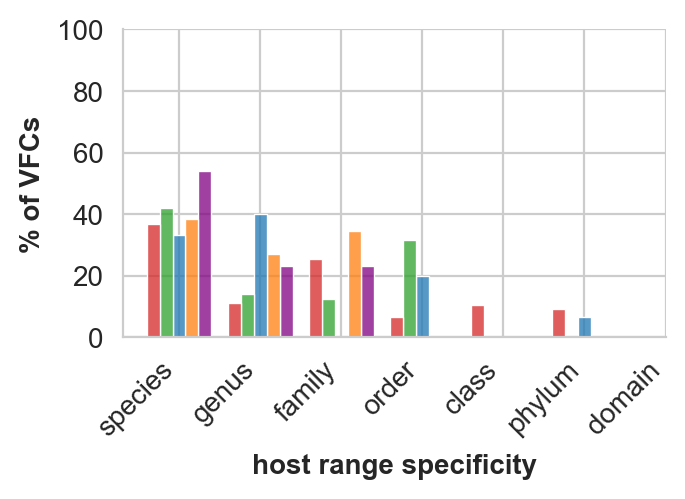

In [10]:
fig, ax = plt.subplots(figsize=(3.5,2), dpi=200)

sns.histplot(data=df_bhr_vfc_p, x='unique_level1', stat='percent', discrete=True, hue='phylum', multiple='dodge', shrink=.8, common_norm=False, ax=ax, palette = colors)

plt.xticks(range(7), taxlevels_rev, rotation=45, ha='right')
plt.xlabel('host range specificity', fontweight='bold')
plt.ylim(0,100)
plt.ylabel('% of VFCs', fontweight='bold')

legend = ax.get_legend()
legend_handles = legend.legend_handles
ax.legend(legend_handles, phyla2plot, title='host phylum', loc='upper right', labelcolor='linecolor', handlelength=0)

ax.legend_.remove()

sns.despine()

In [11]:
from scipy.stats import mannwhitneyu

target = "Firmicutes"

firm = df_bhr_vfc_p.loc[df_bhr_vfc_p["phylum"] == target, "unique_level1"]
others = df_bhr_vfc_p.loc[df_bhr_vfc_p["phylum"] != target, "unique_level1"]

stat, p = mannwhitneyu(firm, others, alternative="greater")
print(f"Firmicutes > Others: U={stat:.0f}, p={p:.1g}")

mean_firm = firm.mean()
mean_others = others.mean()
print(f"Firmicutes mean = {mean_firm:.2f}, Others mean = {mean_others:.2f}")

Firmicutes > Others: U=22324, p=0.008
Firmicutes mean = 1.71, Others mean = 1.19


### Supplementary Fig. 17A: host range specificity of vOTUs and VFCs

In [12]:
df_bhr_votu = df.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
df_bhr_votu['unique_level1'] = df_bhr_votu.unique_level.map(dict_tax)

df_bhr_vfc = df.groupby('VFC', group_keys=False).apply(get_unique_level, level='VFC').reset_index(drop=True)
df_bhr_vfc['unique_level1'] = df_bhr_vfc.unique_level.map(dict_tax)

C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\1374094306.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_bhr_votu = df.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\1374094306.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_bhr_vfc = df.groupby('VFC', group_keys=False).apply(get_unique_level, level='VFC').reset

C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\3380800127.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_bhr_votu, x='unique_level1', stat='percent', discrete=True, ax=ax[0], palette='deep')
C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\3380800127.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df_bhr_vfc, x='unique_level1', stat='percent', discrete=True, ax=ax[1], palette='deep')


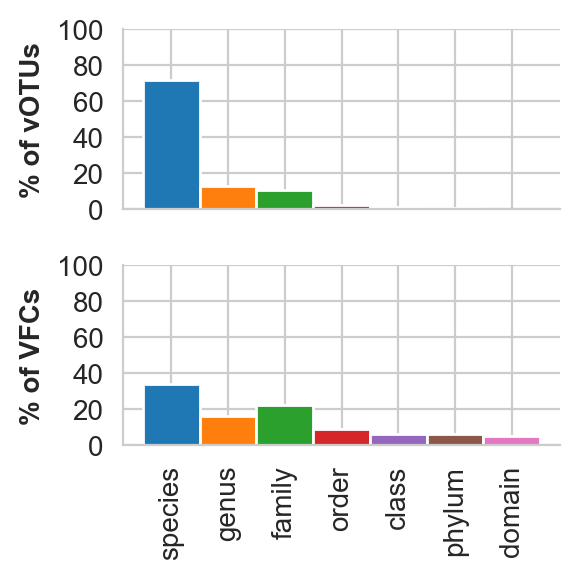

In [13]:
fig, ax = plt.subplots(2,1, figsize=(3,3), dpi=200)

sns.histplot(data=df_bhr_votu, x='unique_level1', stat='percent', discrete=True, ax=ax[0], palette='deep')
sns.histplot(data=df_bhr_vfc, x='unique_level1', stat='percent', discrete=True, ax=ax[1], palette='deep')

ax[0].set_xticks(range(7), ['']*7)
ax[1].set_xticks(range(7), taxlevels_rev, rotation=90)
ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[0].set_ylabel('% of vOTUs', fontweight='bold')
ax[1].set_ylabel('% of VFCs', fontweight='bold')
ax[0].set_ylim(0,100)
ax[1].set_ylim(0,100)
ax[0].set_yticks(range(0,120,20))
ax[1].set_yticks(range(0,120,20))

for i in range(7):
    ax[0].patches[i].set_facecolor(f'C{i}')
    ax[1].patches[i].set_facecolor(f'C{i}')

sns.despine()
plt.tight_layout()

"Most vOTUs (**>84%**) were associated with hosts from a single genus, though evidence from spacer matching and Hi-C data supported broader host ranges in some cases (**15%** of vOTUs infect >1 genera)"

In [14]:
heights_votu = [p.get_height() for p in ax[0].patches]
print('vOTUs: ' + ', '.join([f'{taxlevels_rev[i]}: {round(heights_votu[i], 1)}%' for i in range(7)]))
heights_vfc = [p.get_height() for p in ax[1].patches]
print('VFCs: ' + ', '.join([f'{taxlevels_rev[i]}: {round(heights_vfc[i], 1)}%' for i in range(7)]))

vOTUs: species: 71.9%, genus: 12.8%, family: 10.8%, order: 2.2%, class: 1.1%, phylum: 0.8%, domain: 0.4%
VFCs: species: 34.0%, genus: 16.4%, family: 22.6%, order: 9.3%, class: 6.4%, phylum: 6.2%, domain: 5.2%


### Supplementary Fig. 17B: host range specificity *within* each linkage method

In [15]:
df_bhr_by_linkage = pd.DataFrame()

for l in ['pr','sp','hc']:
    df_l = df.loc[df.linkage_method == l]
    df1 = df_l.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
    df1['linkage_method'] = l
    df_bhr_by_linkage = pd.concat([df_bhr_by_linkage, df1])

df_bhr_by_linkage['unique_level1'] = df_bhr_by_linkage.unique_level.map(dict_tax)

C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\1663511178.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df_l.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
C:\Users\chenhr\AppData\Local\Temp\ipykernel_16580\1663511178.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df1 = df_l.groupby('votu_id', group_keys=False).apply(get_unique_level).reset_index(drop=True)
C:

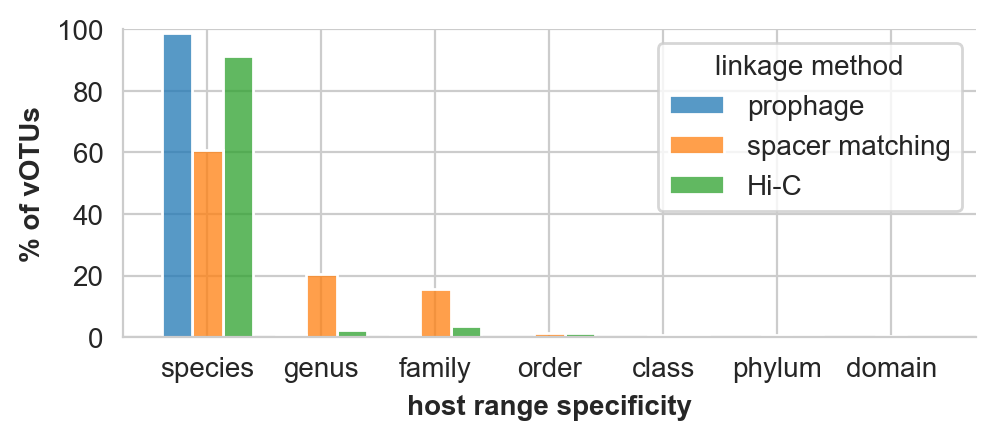

In [16]:
fig, ax = plt.subplots(figsize=(5.5,2), dpi=200)

sns.histplot(data=df_bhr_by_linkage, x='unique_level1', stat='percent', discrete=True, hue='linkage_method', multiple='dodge', shrink=.8, common_norm=False, ax=ax, palette=['C0','C1','C2'])

plt.xticks(range(7), taxlevels_rev)
plt.xlabel('host range specificity', fontweight='bold')
plt.ylim(0,100)
plt.ylabel('% of vOTUs', fontweight='bold')

legend = ax.get_legend()
legend_handles = legend.legend_handles
ax.legend(legend_handles, ['prophage','spacer matching','Hi-C'], title='linkage method', loc='upper right')

sns.despine()

"spacer matching identifies the broadest host ranges of vOTUs, with **19% linking to >1 genus**"

In [17]:
heights = [p.get_height() for p in ax.patches]
heights_prophage = heights[:7]
heights_spacer = heights[7:14]
heights_hic = heights[14:]
print('prophage: ' + ', '.join([f'{taxlevels_rev[i]}: {round(heights_prophage[i], 1)}%' for i in range(7)]))
print('spacer matching: ' + ', '.join([f'{taxlevels_rev[i]}: {round(heights_spacer[i], 1)}%' for i in range(7)]))
print('Hi-C: ' + ', '.join([f'{taxlevels_rev[i]}: {round(heights_hic[i], 1)}%' for i in range(7)]))

prophage: species: 91.3%, genus: 2.4%, family: 3.5%, order: 1.3%, class: 0.8%, phylum: 0.5%, domain: 0.2%
spacer matching: species: 60.8%, genus: 20.4%, family: 15.7%, order: 1.4%, class: 0.7%, phylum: 0.6%, domain: 0.3%
Hi-C: species: 98.6%, genus: 0.7%, family: 0.6%, order: 0.1%, class: 0.0%, phylum: 0.0%, domain: 0.0%
